In [1]:
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt

In [2]:
hr=pd.read_csv('../data/raw/subject_01/night_1/hr.csv')
hr.columns=['timestamp','bpm']
print(hr.shape)
print(hr.head)
print(hr.dtypes)
print(hr['bpm'].describe())

(4790, 2)
<bound method NDFrame.head of          timestamp   bpm
0     1.638505e+09  68.0
1     1.638505e+09  67.0
2     1.638505e+09  67.0
3     1.638505e+09  66.0
4     1.638505e+09  65.0
...            ...   ...
4785  1.638533e+09  64.0
4786  1.638533e+09  65.0
4787  1.638533e+09  67.0
4788  1.638533e+09  67.0
4789  1.638533e+09  68.0

[4790 rows x 2 columns]>
timestamp    float64
bpm          float64
dtype: object
count    4790.000000
mean       58.813152
std         4.489652
min        49.000000
25%        56.000000
50%        58.000000
75%        61.000000
max        93.000000
Name: bpm, dtype: float64


In [3]:
motion = pd.read_csv('../data/raw/subject_01/night_1/motion.csv')
print(motion.shape)
print(motion.head())
print(motion.dtypes)
print(motion.describe())

C:\Users\khush\AppData\Local\Temp\ipykernel_14476\246076994.py:1: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  motion = pd.read_csv('../data/raw/subject_01/night_1/motion.csv')


(1400996, 4)
            Timestamp                    x                    y  \
0   1638504587.431474    -0.09625244140625  -0.1859893798828125   
1   1638504587.451272   -0.098297119140625  -0.1881561279296875   
2  1638504587.4713101  -0.0814361572265625  -0.1732940673828125   
3  1638504587.4913611  -0.0955963134765625   -0.177947998046875   
4  1638504587.5113711  -0.0878448486328125   -0.171478271484375   

                     z  
0  -0.9643707275390625  
1  -0.9690704345703125  
2   -0.983489990234375  
3  -0.9824676513671875  
4      -0.982177734375  
Timestamp    object
x            object
y            object
z            object
dtype: object
                 Timestamp             x             y             z
count              1400996  1.400996e+06  1.400996e+06  1.400996e+06
unique             1400984  5.119000e+04  6.692500e+04  6.320200e+04
top     1638504587.4713101  1.433868e-01 -9.706268e-01 -9.952850e-01
freq                     2  7.530000e+02  7.170000e+02  8.720000

In [4]:
print(motion.isnull().sum())
print(hr.isnull().sum())

Timestamp    0
x            0
y            0
z            0
dtype: int64
timestamp    0
bpm          0
dtype: int64


In [5]:
labels_raw = scipy.io.loadmat('../data/raw/subject_01/night_1/labels.mat')
print(labels_raw.keys())

dict_keys(['__header__', '__version__', '__globals__', 'dreem_label', 'expert_label', 'recStart'])


In [6]:
labels = labels_raw['expert_label'].flatten()
print(labels.shape)
print(np.unique(labels))
print(labels[:20])

(935,)
[0 1 2 3 4]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]


In [7]:
print(labels_raw['recStart'])
print(labels_raw['expert_label'].flatten().shape)
print(labels_raw['dreem_label'].flatten().shape)

labels = labels_raw['expert_label'].flatten()
print(np.unique(labels))
print(len(labels))
labels[:20]

['2021-12-02 23:11:25']
(935,)
(935,)
[0 1 2 3 4]
935


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
      dtype=uint8)

In [8]:
motion['Timestamp'] = pd.to_numeric(motion['Timestamp'], errors='coerce')
motion['x'] = pd.to_numeric(motion['x'], errors='coerce')
motion['y'] = pd.to_numeric(motion['y'], errors='coerce')
motion['z'] = pd.to_numeric(motion['z'], errors='coerce')

In [9]:
hr_start = hr['timestamp'].min()
hr_end = hr['timestamp'].max()
hr_duration = (hr_end - hr_start)/3600

motion_start = motion['Timestamp'].min()
motion_end = motion['Timestamp'].max()
motion_duration = (motion_end - motion_start) / 3600

print(f"HR duration: {hr_duration:.2f} hours")
print(f"Motion duration: {motion_duration:.2f} hours")
print(f"Number of labels: {len(labels)}")
print(f"Label duration: {len(labels) * 30 / 3600:.2f} hours")

HR duration: 7.80 hours
Motion duration: 7.81 hours
Number of labels: 935
Label duration: 7.79 hours


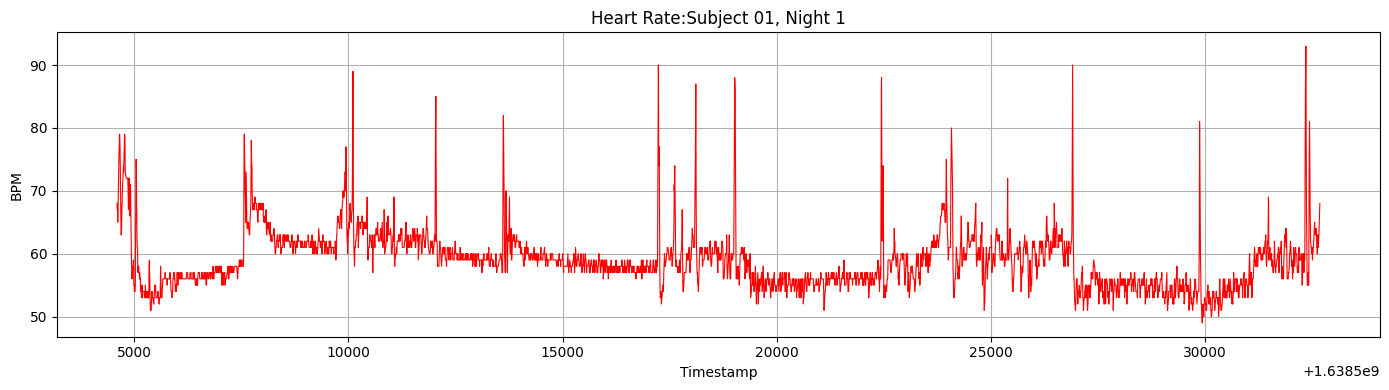

In [10]:
plt.figure(figsize=(14, 4))
plt.plot(hr['timestamp'], hr['bpm'], color='red', linewidth=0.8)
plt.xlabel('Timestamp')
plt.ylabel('BPM')
plt.title('Heart Rate:Subject 01, Night 1')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\khush\AppData\Local\Temp\ipykernel_14476\2037333502.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


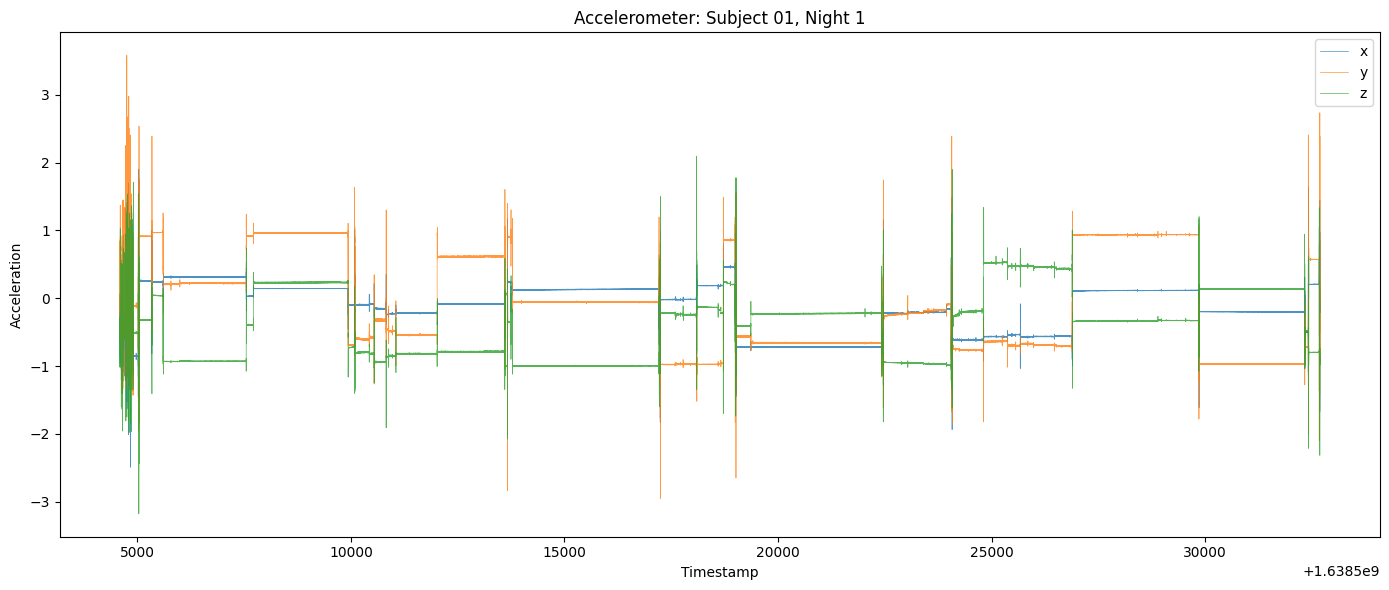

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(motion['Timestamp'], motion['x'], label='x', linewidth=0.5, alpha=0.8)
plt.plot(motion['Timestamp'], motion['y'], label='y', linewidth=0.5, alpha=0.8)
plt.plot(motion['Timestamp'], motion['z'], label='z', linewidth=0.5, alpha=0.8)
plt.xlabel('Timestamp')
plt.ylabel('Acceleration')
plt.title('Accelerometer: Subject 01, Night 1')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
import collections
label_map = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}

counts = collections.Counter(labels)
for k, v in sorted(counts.items()):
    name = label_map.get(k, f'Unknown-{k}')
    pct = v / len(labels) * 100
    print(f"{name}: {v} epochs ({pct:.1f}%)")

Wake: 36 epochs (3.9%)
N1: 31 epochs (3.3%)
N2: 347 epochs (37.1%)
N3: 273 epochs (29.2%)
REM: 248 epochs (26.5%)


In [13]:
from datetime import datetime

In [14]:
rec_start_str = str(labels_raw['recStart'][0])

In [15]:
print(f"HR shape:     {hr.shape}")
print(f"Motion shape: {motion.shape}")
print(f"Labels shape: {labels.shape}")
print(f"recStart:     {rec_start_str}")

HR shape:     (4790, 2)
Motion shape: (1400996, 4)
Labels shape: (935,)
recStart:     2021-12-02 23:11:25


In [16]:
hr['timestamp'] = hr['timestamp'].astype(float)
hr['datetime'] = pd.to_datetime(hr['timestamp'], unit='s')

print(f"HR first datetime: {hr['datetime'].iloc[0]}")
print(f"HR last datetime:  {hr['datetime'].iloc[-1]}")

HR first datetime: 2021-12-03 04:09:58.029795647
HR last datetime:  2021-12-03 11:57:57.235663414


In [17]:
motion['Timestamp'] = motion['Timestamp'].astype(float)
motion['datetime'] = pd.to_datetime(motion['Timestamp'], unit='s')

print(f"Motion first datetime: {motion['datetime'].iloc[0]}")
print(f"Motion last datetime:  {motion['datetime'].iloc[-1]}")

Motion first datetime: 2021-12-03 04:09:47.431473970
Motion last datetime:  2021-12-03 11:58:09.645339012


In [18]:
print(repr(rec_start_str))
print(type(rec_start_str))

'2021-12-02 23:11:25'
<class 'str'>


In [19]:
#(without timezone adjustment)
rec_start = pd.Timestamp(rec_start_str)

#gap between recStart and first HR reading
offset_seconds = (hr['datetime'].iloc[0] - rec_start).total_seconds()

# Shift recStart forward by that offset
rec_start_utc = rec_start + pd.Timedelta(seconds=offset_seconds)

# Verify
print(f"Original recStart:  {rec_start}")
print(f"Adjusted recStart:  {rec_start_utc}")
print(f"HR first:           {hr['datetime'].iloc[0]}")
print(f"Difference now:     {(hr['datetime'].iloc[0] - rec_start_utc).total_seconds():.1f} seconds")

Original recStart:  2021-12-02 23:11:25
Adjusted recStart:  2021-12-03 04:09:58.029795
HR first:           2021-12-03 04:09:58.029795647
Difference now:     0.0 seconds


In [20]:
epoch_duration = 30 #(30 seconds per epoch)
n_epochs = len(labels)
epoch_starts = []
for i in range(n_epochs):
    start = rec_start_utc + pd.Timedelta(seconds=i * epoch_duration)
    epoch_starts.append(start)

epoch_ends = []
for i in range(n_epochs):
    end = rec_start_utc + pd.Timedelta(seconds=(i + 1) * epoch_duration)
    epoch_ends.append(end)

In [21]:
print(f"Epoch 0:   {epoch_starts[0]}  →  {epoch_ends[0]}")
print(f"Epoch 1:   {epoch_starts[1]}  →  {epoch_ends[1]}")
print(f"Epoch 934: {epoch_starts[934]}  →  {epoch_ends[934]}")

Epoch 0:   2021-12-03 04:09:58.029795  →  2021-12-03 04:10:28.029795
Epoch 1:   2021-12-03 04:10:28.029795  →  2021-12-03 04:10:58.029795
Epoch 934: 2021-12-03 11:56:58.029795  →  2021-12-03 11:57:28.029795


In [22]:
print(f"\nHR last timestamp:  {hr['datetime'].iloc[-1]}")
print(f"Last epoch end:     {epoch_ends[934]}")
print(f"Tail difference:    {(hr['datetime'].iloc[-1] - epoch_ends[934]).total_seconds():.1f} seconds")


HR last timestamp:  2021-12-03 11:57:57.235663414
Last epoch end:     2021-12-03 11:57:28.029795
Tail difference:    29.2 seconds


In [23]:
def get_hr_for_epoch(hr_df,start,end):
    mask = (hr_df['datetime']>=start) & (hr_df['datetime']<end)
    return hr_df.loc[mask, 'bpm'].values

def get_acc_for_epoch(motion_df,start,end):
    mask = (motion_df['datetime']>=start) & (motion_df['datetime']<end)
    return motion_df.loc[mask,['x','y','z']]

In [24]:
for i in range(3):
    hr_vals  = get_hr_for_epoch(hr, epoch_starts[i], epoch_ends[i])
    acc_vals = get_acc_for_epoch(motion, epoch_starts[i], epoch_ends[i])
    print(f"Epoch {i} | label={labels[i]} | HR={len(hr_vals)} readings | ACC={acc_vals.shape}")

Epoch 0 | label=0 | HR=7 readings | ACC=(1495, 3)


Epoch 1 | label=0 | HR=4 readings | ACC=(1496, 3)
Epoch 2 | label=0 | HR=3 readings | ACC=(1496, 3)


In [25]:
aligned_data = []

for i in range(n_epochs):
    start    = epoch_starts[i]
    end      = epoch_ends[i]
    hr_vals  = get_hr_for_epoch(hr, start, end)
    acc_vals = get_acc_for_epoch(motion, start, end)
    label    = labels[i]

    aligned_data.append({
        'epoch_idx':    i,
        'hr_readings':  hr_vals,
        'acc_readings': acc_vals,
        'label':        label
    })

print(f"Total epochs aligned: {len(aligned_data)}")

Total epochs aligned: 935


In [26]:
hr_counts  = [len(d['hr_readings']) for d in aligned_data]
acc_counts = [d['acc_readings'].shape[0] for d in aligned_data]

print(f"HR  — Min: {min(hr_counts)},  Max: {max(hr_counts)},  Mean: {np.mean(hr_counts):.1f}")
print(f"ACC — Min: {min(acc_counts)}, Max: {max(acc_counts)}, Mean: {np.mean(acc_counts):.1f}")
print(f"Epochs with 0 HR readings:  {hr_counts.count(0)}")
print(f"Epochs with 0 ACC readings: {acc_counts.count(0)}")

HR  — Min: 1,  Max: 7,  Mean: 5.1
ACC — Min: 1493, Max: 1496, Mean: 1495.6
Epochs with 0 HR readings:  0
Epochs with 0 ACC readings: 0


In [27]:
import pickle

In [28]:
with open('../data/processed/subject_01/night_1/aligned_data.pkl', 'wb') as f:
    pickle.dump(aligned_data, f)

print(f"Saved — aligned_data.pkl")
print(f"935 epochs, each contains hr_readings, acc_readings, label")

Saved — aligned_data.pkl
935 epochs, each contains hr_readings, acc_readings, label
